# Actividad 1 · Gobierno del dato y toma de decisiones
## Parte I-A · Análisis Exploratorio de Datos (EDA) previo a la carga en Dremio

**Contenido**
1. Carga y visión general
2. Datos faltantes
3. Distribución de variables y outliers
4. Relaciones entre variables
5. Inconsistencias
6. Hallazgos y reflexión
7. Limpieza y exportación para Dremio

**Antes de ejecutar:** crea una carpeta `datos/` junto a este notebook con los 4 ficheros originales
y ejecuta `pip install pandas matplotlib seaborn missingno`.

In [1]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import missingno as msno
import numpy as np
import pandas as pd
import seaborn as sns

pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 200)
sns.set_theme(style="whitegrid")

DATA_DIR = Path("datos")
CLEAN_DIR = Path("datos_limpios")

## 1. Carga y visión general

In [2]:
def leer_csv(nombre, enc):
    # Todo como texto: evitamos que pandas adivine tipos y así podemos detectar inconsistencias
    return pd.read_csv(DATA_DIR / nombre, sep=";", encoding=enc, dtype=str,
                       keep_default_na=False, na_values=[""])

def a_numero(serie):
    # '7,2' -> 7.2 (coma decimal española a punto)
    return pd.to_numeric(serie.str.replace(",", ".", regex=False), errors="coerce")

terr = leer_csv("Terrazas_202104.csv", "latin1")
lic  = leer_csv("Licencias_Locales_202104.csv", "utf-8")
loc  = leer_csv("Locales_202104.csv", "latin1")

with open(DATA_DIR / "books.json", encoding="utf-8") as f:
    filas_books = [json.loads(l) for l in f if l.strip()]
books = pd.json_normalize(filas_books)

resumen = pd.DataFrame({
    "filas": [len(terr), len(lic), len(loc), len(books)],
    "columnas": [terr.shape[1], lic.shape[1], loc.shape[1], books.shape[1]],
}, index=["Terrazas_202104", "Licencias_Locales_202104", "Locales_202104", "books"])
resumen

,filas,columnas
Terrazas_202104,6275,57
Licencias_Locales_202104,132171,46
Locales_202104,148216,40
books,431,12


Vista previa de `Terrazas_202104` (`head`, `tail`, `sample`):

In [3]:
display(terr.head(3))
display(terr.tail(3))
display(terr.sample(3, random_state=1))

,id_terraza,id_local,id_distrito_local,desc_distrito_local,id_barrio_local,desc_barrio_local,id_ndp_edificio,id_clase_ndp_edificio,id_vial_edificio,clase_vial_edificio,desc_vial_edificio,nom_edificio,num_edificio,Cod_Postal,coordenada_x_local,coordenada_y_local,id_tipo_acceso_local,desc_tipo_acceso_local,id_situacion_local,desc_situacion_local,secuencial_local_PC,Escalera,id_planta_agrupado,id_local_agrupado,coordenada_x_agrupacion,coordenada_y_agrupacion,rotulo,id_periodo_terraza,desc_periodo_terraza,id_situacion_terraza,desc_situacion_terraza,Superficie_ES,Superficie_RA,Fecha_confir_ult_decreto_resol,id_ndp_terraza,id_clase_ndp_terraza,ID_VIAL,DESC_CLASE,DESC_NOMBRE,nom_terraza,num_terraza,cal_terraza,desc_ubicacion_terraza,hora_ini_LJ_es,hora_fin_LJ_es,hora_ini_LJ_ra,hora_fin_LJ_ra,hora_ini_VS_es,hora_fin_VS_es,hora_ini_VS_ra,hora_fin_VS_ra,mesas_aux_es,mesas_aux_ra,mesas_es,mesas_ra,sillas_es,sillas_ra
0,7,280067128,20,SAN BLAS-CANILLEJAS,2005,ROSAS,20157611,1,2443,CALLE,SOFIA ...,NUM,177,28022,"448900,55","4474755,41",1,Puerta Calle,1,Abierto,10,NaN,PB,NaN,NaN,NaN,SR,2,Estacional,1,Abierta,"7,2",NaN,24/03/2014,20157611,1,2443,CALLE,SOFIA ...,NUM,177,A,Acera,08:00:00,01:30:00,NaN,NaN,08:00:00,01:30:00,NaN,NaN,0,NaN,5,NaN,10,A
1,33,270403150,4,SALAMANCA,404,GUINDALERA,11018870,1,42500,AVENIDA,AMERICA ...,NUM,2,28028,"442586,58","4476524,51",1,Puerta Calle,1,Abierto,30,NaN,PB,NaN,NaN,NaN,HONTANARES,1,Anual,1,Abierta,"21,06","21,06",04/04/2014,11018870,1,42500,AVENIDA,AMERICA ...,NUM,2,,Acera,10:00:00,01:00:00,10:00:00,00:00:00,10:00:00,02:30:00,10:00:00,00:00:00,0,0,9,9,27,
2,34,270078567,4,SALAMANCA,404,GUINDALERA,11018555,1,35200,CALLE,ALONSO HEREDIA ...,NUM,25,28028,"442986,58","4476379,5",1,Puerta Calle,1,Abierto,10,NaN,PB,NaN,NaN,NaN,BAR MARISQUERIA LUIS,1,Anual,1,Abierta,"11,16","11,16",04/04/2014,11018555,1,35200,CALLE,ALONSO HEREDIA ...,NUM,25,,Calle peatonal,10:00:00,01:00:00,10:00:00,00:00:00,10:00:00,02:30:00,10:00:00,00:00:00,0,0,4,0,14,


,id_terraza,id_local,id_distrito_local,desc_distrito_local,id_barrio_local,desc_barrio_local,id_ndp_edificio,id_clase_ndp_edificio,id_vial_edificio,clase_vial_edificio,desc_vial_edificio,nom_edificio,num_edificio,Cod_Postal,coordenada_x_local,coordenada_y_local,id_tipo_acceso_local,desc_tipo_acceso_local,id_situacion_local,desc_situacion_local,secuencial_local_PC,Escalera,id_planta_agrupado,id_local_agrupado,coordenada_x_agrupacion,coordenada_y_agrupacion,rotulo,id_periodo_terraza,desc_periodo_terraza,id_situacion_terraza,desc_situacion_terraza,Superficie_ES,Superficie_RA,Fecha_confir_ult_decreto_resol,id_ndp_terraza,id_clase_ndp_terraza,ID_VIAL,DESC_CLASE,DESC_NOMBRE,nom_terraza,num_terraza,cal_terraza,desc_ubicacion_terraza,hora_ini_LJ_es,hora_fin_LJ_es,hora_ini_LJ_ra,hora_fin_LJ_ra,hora_ini_VS_es,hora_fin_VS_es,hora_ini_VS_ra,hora_fin_VS_ra,mesas_aux_es,mesas_aux_ra,mesas_es,mesas_ra,sillas_es,sillas_ra
6272,18670,50000979,5,CHAMARTIN,501,EL VISO,11021035,1,706600,CALLE,SEGRE ...,NUM,25,28002,"441896,59","4478065,52",1,Puerta Calle,1,Abierto,10,NaN,PB,NaN,NaN,NaN,CAFÉ SEGRE,1,Anual,1,Abierta,21,21,30/04/2021,11021035,1,706600,CALLE,SEGRE ...,NUM,25,,Zona de estacionamiento,10:00:00,01:00:00,10:00:00,00:00:00,10:00:00,02:30:00,10:00:00,00:00:00,1,1,3,3,12,
6273,18671,270326669,5,CHAMARTIN,503,CIUDAD JARDIN,11023804,1,293400,CALLE,FERNANDEZ DE OVIEDO ...,NUM,18,28002,"443019,59","4477587,5",1,Puerta Calle,1,Abierto,20,NaN,PB,NaN,NaN,NaN,RESTAURANTE LA PROSPERIDAD,1,Anual,1,Abierta,"24,83","24,83",30/04/2021,11023804,1,293400,CALLE,FERNANDEZ DE OVIEDO ...,NUM,18,,Zona de estacionamiento,10:00:00,01:00:00,10:00:00,00:00:00,10:00:00,02:30:00,10:00:00,00:00:00,0,0,4,4,16,
6274,18672,270243087,3,RETIRO,301,PACIFICO,11010860,1,158900,CALLE,CAVANILLES ...,NUM,18,28007,"442534,58","4473090,5",1,Puerta Calle,1,Abierto,10,NaN,PB,NaN,NaN,NaN,BAR LIDER,2,Estacional,1,Abierta,"19,08",NaN,30/04/2021,11010860,1,158900,CALLE,CAVANILLES ...,NUM,18,,Acera,10:00:00,01:00:00,NaN,NaN,10:00:00,02:30:00,NaN,NaN,0,0,7,0,24,


,id_terraza,id_local,id_distrito_local,desc_distrito_local,id_barrio_local,desc_barrio_local,id_ndp_edificio,id_clase_ndp_edificio,id_vial_edificio,clase_vial_edificio,desc_vial_edificio,nom_edificio,num_edificio,Cod_Postal,coordenada_x_local,coordenada_y_local,id_tipo_acceso_local,desc_tipo_acceso_local,id_situacion_local,desc_situacion_local,secuencial_local_PC,Escalera,id_planta_agrupado,id_local_agrupado,coordenada_x_agrupacion,coordenada_y_agrupacion,rotulo,id_periodo_terraza,desc_periodo_terraza,id_situacion_terraza,desc_situacion_terraza,Superficie_ES,Superficie_RA,Fecha_confir_ult_decreto_resol,id_ndp_terraza,id_clase_ndp_terraza,ID_VIAL,DESC_CLASE,DESC_NOMBRE,nom_terraza,num_terraza,cal_terraza,desc_ubicacion_terraza,hora_ini_LJ_es,hora_fin_LJ_es,hora_ini_LJ_ra,hora_fin_LJ_ra,hora_ini_VS_es,hora_fin_VS_es,hora_ini_VS_ra,hora_fin_VS_ra,mesas_aux_es,mesas_aux_ra,mesas_es,mesas_ra,sillas_es,sillas_ra
4358,6541,280000012,4,SALAMANCA,401,RECOLETOS,11013653,1,88904333,CALLE,ALCALA ...,NUM,61,28014,"441368,59","4474592,52",1,Puerta Calle,1,Abierto,10,NaN,PB,NaN,NaN,NaN,FABORIT,1,Anual,1,Abierta,"18,83","18,83",29/12/2017,11013653,1,88904333,CALLE,ALCALA ...,NUM,61,,Acera,08:00:00,01:30:00,08:00:00,01:00:00,08:00:00,01:30:00,08:00:00,01:00:00,0,0,6,6,15,
1009,1534,270411097,5,CHAMARTIN,505,NUEVA ESPAÑA,11025648,1,241800,CALLE,DOCTOR FLEMING ...,NUM,31,28036,"441666,6","4479169,53",1,Puerta Calle,1,Abierto,30,NaN,PB,NaN,NaN,NaN,RESTAURANTE ASIÁTICO LONGAN,2,Estacional,1,Abierta,"37,43",NaN,17/02/2015,11025648,1,241800,CALLE,DOCTOR FLEMING ...,NUM,31,,Acera,10:00:00,01:00:00,NaN,NaN,10:00:00,02:30:00,NaN,NaN,0,NaN,12,NaN,42,
2717,4224,270126116,7,CHAMBERI,706,VALLEHERMOSO,11042576,1,108600,CALLE,BLASCO DE GARAY ...,NUM,100,28003,"439716,6","4476798,54",1,Puerta Calle,1,Abierto,20,NaN,PB,NaN,NaN,NaN,LA HEMEROTECA BAR,1,Anual,1,Abierta,"25,41","25,41",05/12/2016,11042589,1,297025,AVENIDA,FILIPINAS ...,NUM,14,,Acera,08:00:00,01:30:00,08:00:00,01:00:00,08:00:00,01:30:00,08:00:00,01:00:00,0,0,8,8,24,


Tipos de datos: si pandas infiere los tipos por su cuenta, las superficies con coma decimal quedan como texto
(mismo problema que tendría Dremio).

In [4]:
terr_auto = pd.read_csv(DATA_DIR / "Terrazas_202104.csv", sep=";", encoding="latin1")
print(terr_auto[["id_terraza", "id_local", "Superficie_ES", "Superficie_RA", "coordenada_x_local"]].dtypes)

id_terraza            int64
id_local              int64
Superficie_ES           str
Superficie_RA           str
coordenada_x_local      str
dtype: object


Estadísticas básicas de las variables numéricas de `Terrazas` (tras convertir la coma decimal):

In [5]:
cols_num = ["Superficie_ES", "Superficie_RA", "mesas_es", "mesas_ra", "sillas_es", "sillas_ra"]
terr_num = terr[cols_num].apply(a_numero)
terr_num.describe().round(2)

,Superficie_ES,Superficie_RA,mesas_es,mesas_ra,sillas_es,sillas_ra
count,6275.00,4809.00,6275.00,4770.00,6275.00,0.0
mean,33.46,32.23,9.71,9.13,31.63,NaN
std,39.76,35.12,11.35,7.15,24.54,NaN
min,0.63,0.63,0.00,0.00,0.00,NaN
25%,14.04,14.01,5.00,5.00,15.50,NaN
50%,25.56,25.15,8.00,8.00,24.00,NaN
75%,41.20,39.86,12.00,12.00,40.00,NaN
max,920.00,824.00,715.00,112.00,408.00,NaN


## 2. Datos faltantes

In [6]:
def resumen_nulos(df, nombre):
    pct = (df.isna().mean() * 100).round(1)
    print(f"{nombre}: {int((df.isna().mean(axis=1) > 0.5).sum())} filas con más del 50 % de nulos")
    print("Columnas con más del 50 % de nulos:")
    display(pct[pct > 50].sort_values(ascending=False).to_frame("% nulos"))

for df, n in [(terr, "Terrazas"), (lic, "Licencias_Locales"), (loc, "Locales")]:
    resumen_nulos(df, n)

Terrazas: 0 filas con más del 50 % de nulos
Columnas con más del 50 % de nulos:


,% nulos
Escalera,100.0
id_local_agrupado,98.5
coordenada_x_agrupacion,98.5
coordenada_y_agrupacion,98.5


Licencias_Locales: 0 filas con más del 50 % de nulos
Columnas con más del 50 % de nulos:


,% nulos
coordenada_x_agrupacion,93.8
coordenada_y_agrupacion,93.8
id_local_agrupado,93.8


Locales: 0 filas con más del 50 % de nulos
Columnas con más del 50 % de nulos:


,% nulos
cod_barrio_local,100.0
id_seccion_censal_local,100.0
id_tipo_acceso_local,100.0
id_vial_edificio,100.0
id_vial_acceso,100.0
id_local_agrupado,90.5
coordenada_y_agrup,90.4
coordenada_x_agrupacion,90.4
id_agrupacion,90.4
nombre_agrupacion,90.4


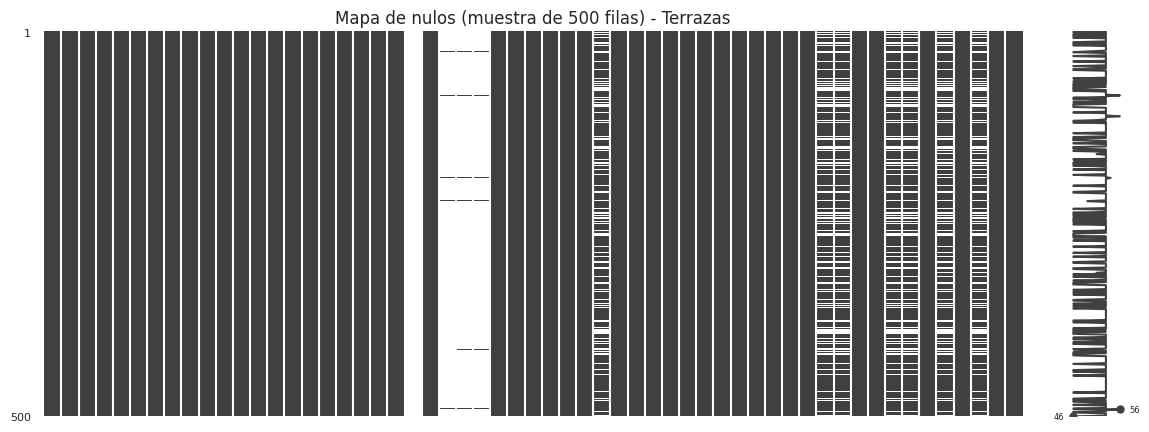

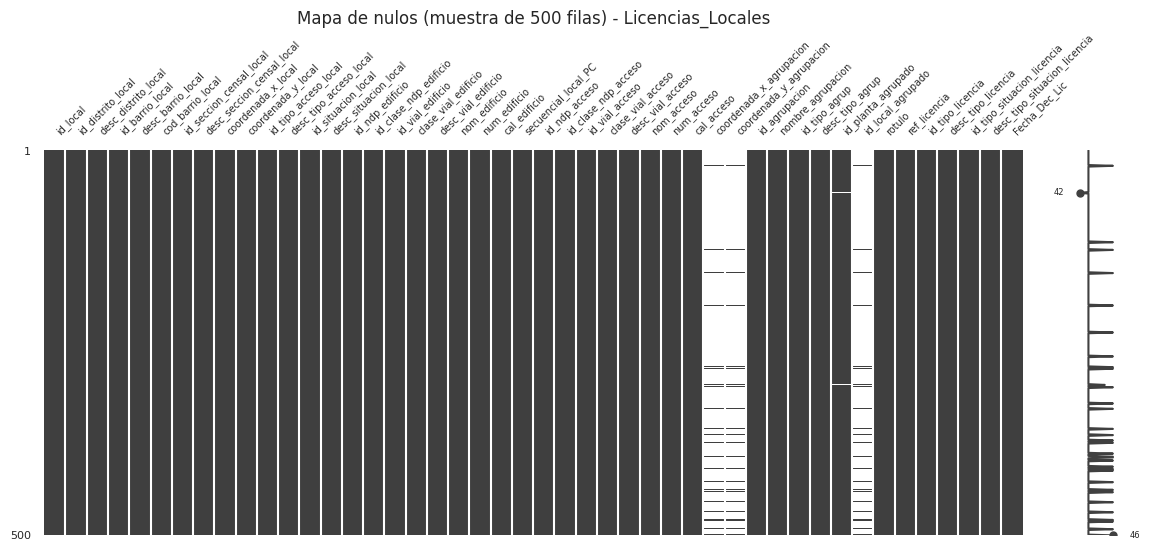

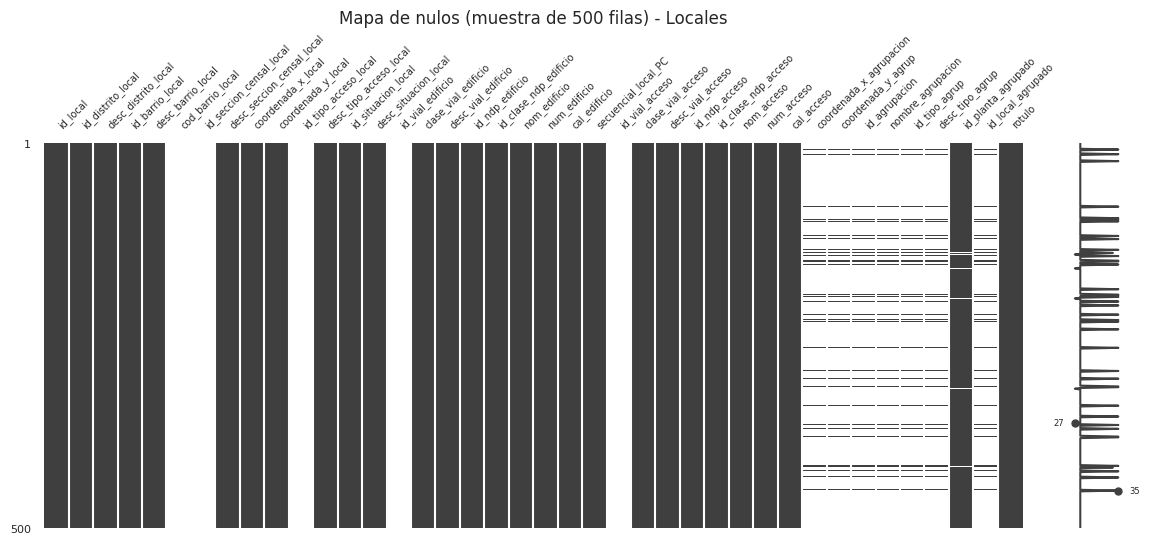

In [7]:
for df, n in [(terr, "Terrazas"), (lic, "Licencias_Locales"), (loc, "Locales")]:
    msno.matrix(df.sample(500, random_state=1), figsize=(14, 5), fontsize=7)
    plt.title(f"Mapa de nulos (muestra de 500 filas) - {n}")
    plt.show()

In [8]:
print("Superficie_RA nulos:", terr["Superficie_RA"].isna().sum(), "de", len(terr))
print("Superficie_ES nulos:", terr["Superficie_ES"].isna().sum())
print("Books sin ISBN:", books["isbn"].isna().sum(), "| sin fecha:", books["publishedDate.$date"].isna().sum(),
      "| sin shortDescription:", books["shortDescription"].isna().sum())

Superficie_RA nulos: 1466 de 6275
Superficie_ES nulos: 0
Books sin ISBN: 3 | sin fecha: 78 | sin shortDescription: 271


## 3. Distribución de variables y outliers

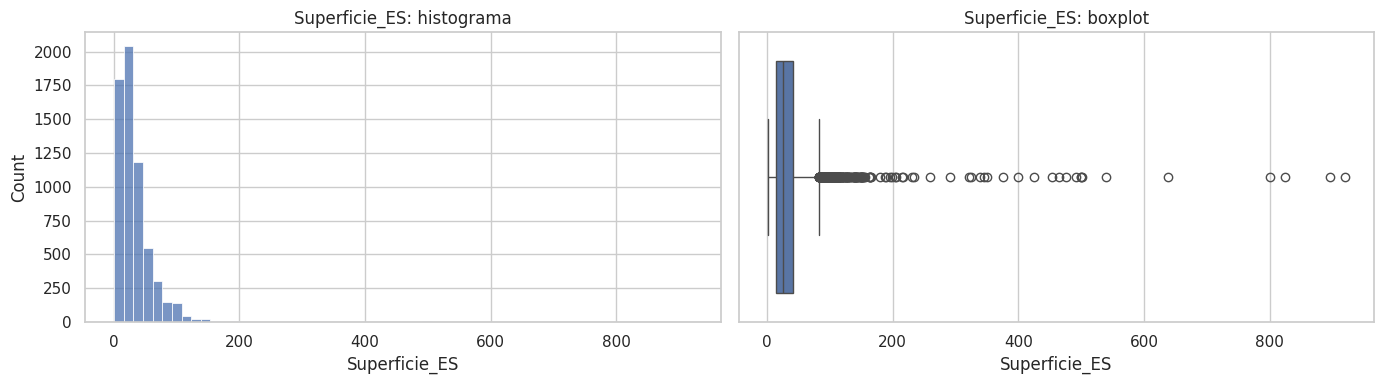

Mediana: 25.56 m2 | máximo: 920 m2 | límite IQR: 81.9 m2
Terrazas por encima del límite IQR: 350 | por encima de 200 m2: 29


In [9]:
fig, ax = plt.subplots(1, 2, figsize=(14, 4))
sns.histplot(terr_num["Superficie_ES"], bins=60, ax=ax[0])
ax[0].set_title("Superficie_ES: histograma")
sns.boxplot(x=terr_num["Superficie_ES"], ax=ax[1])
ax[1].set_title("Superficie_ES: boxplot")
plt.tight_layout(); plt.show()

s = terr_num["Superficie_ES"]
q1, q3 = s.quantile([0.25, 0.75])
lim = q3 + 1.5 * (q3 - q1)
print(f"Mediana: {s.median():.2f} m2 | máximo: {s.max():.0f} m2 | límite IQR: {lim:.1f} m2")
print("Terrazas por encima del límite IQR:", (s > lim).sum(), "| por encima de 200 m2:", (s > 200).sum())

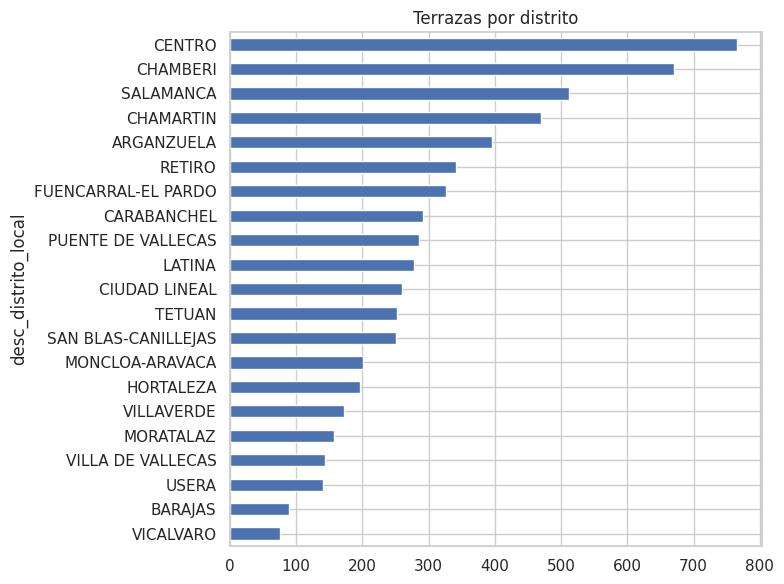

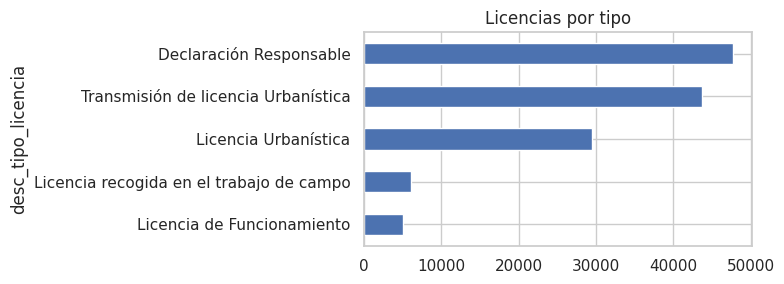

In [10]:
distritos = terr["desc_distrito_local"].str.strip().value_counts().sort_values()
distritos.plot.barh(figsize=(8, 6), title="Terrazas por distrito")
plt.tight_layout(); plt.show()

lic["desc_tipo_licencia"].value_counts().sort_values().plot.barh(figsize=(8, 3), title="Licencias por tipo")
plt.tight_layout(); plt.show()

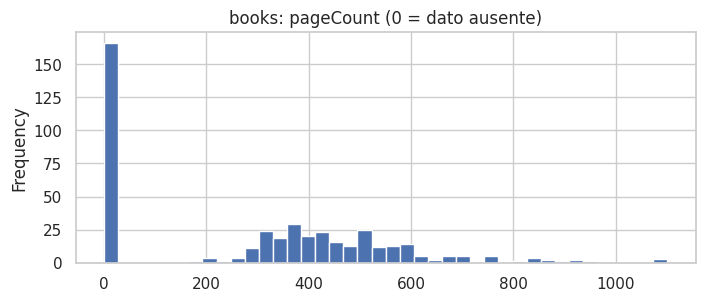

Libros con pageCount = 0: 166
Nº de autores por libro:
authors
0     37
1    206
2    105
3      9
4     47
5     16
6      6
7      2
8      3


In [11]:
books["pageCount"].plot.hist(bins=40, figsize=(8, 3), title="books: pageCount (0 = dato ausente)")
plt.show()
print("Libros con pageCount = 0:", (books["pageCount"] == 0).sum())
print("Nº de autores por libro:")
print(books["authors"].map(len).value_counts().sort_index().to_string())

## 4. Relaciones entre variables

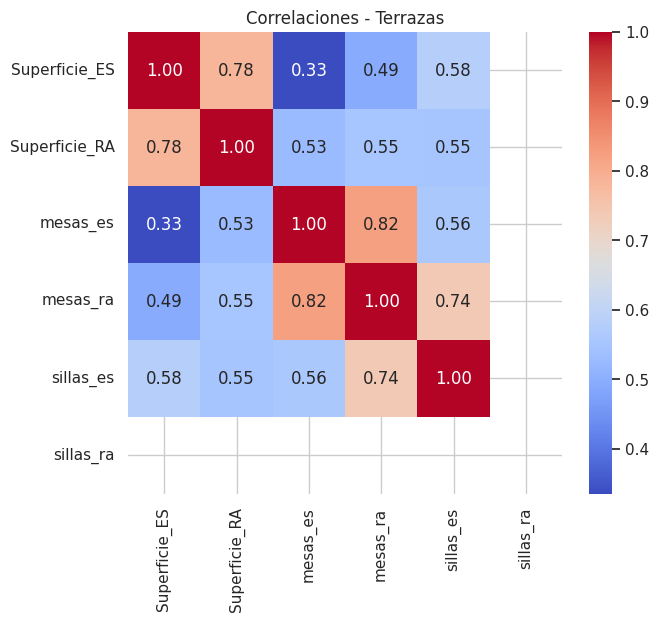

In [12]:
plt.figure(figsize=(7, 6))
sns.heatmap(terr_num.corr(), annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Correlaciones - Terrazas")
plt.show()

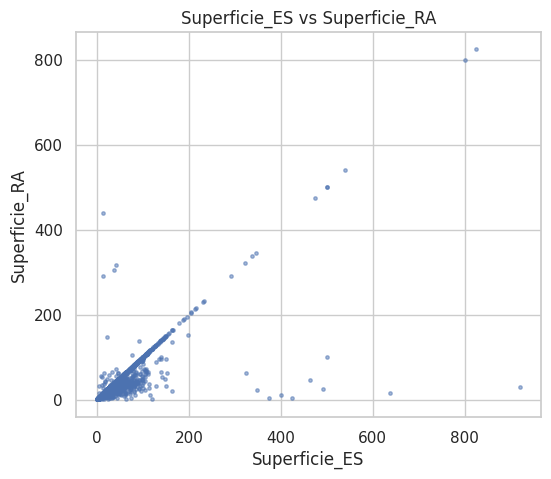

In [13]:
plt.figure(figsize=(6, 5))
plt.scatter(terr_num["Superficie_ES"], terr_num["Superficie_RA"], s=6, alpha=0.5)
plt.xlabel("Superficie_ES"); plt.ylabel("Superficie_RA"); plt.title("Superficie_ES vs Superficie_RA")
plt.show()

## 5. Inconsistencias

**5.1 Textos con espacios de relleno**: aquí no fragmentan categorías (el relleno es uniforme), pero rompen filtros por igualdad y joins con otras fuentes:

In [14]:
antes = terr["desc_distrito_local"].nunique()
despues = terr["desc_distrito_local"].str.strip().nunique()
print("Terrazas · valores distintos de desc_distrito_local: antes =", antes, "| tras strip =", despues)
print(repr(terr["desc_distrito_local"].iloc[0]), "->", repr(terr["desc_distrito_local"].iloc[0].strip()))
print("Filas con distrito = 'CENTRO' (sin recortar):", (terr["desc_distrito_local"] == "CENTRO").sum(),
      "| recortando:", (terr["desc_distrito_local"].str.strip() == "CENTRO").sum())

Terrazas · valores distintos de desc_distrito_local: antes = 21 | tras strip = 21
'SAN BLAS-CANILLEJAS ' -> 'SAN BLAS-CANILLEJAS'
Filas con distrito = 'CENTRO' (sin recortar): 0 | recortando: 765


**5.2 Duplicados, fechas y cobertura del JOIN Terrazas-Licencias**

In [15]:
print("Filas duplicadas exactas -> Terrazas:", terr.duplicated().sum(),
      "| Licencias:", lic.duplicated().sum(), "| Locales:", loc.duplicated().sum())
print("Duplicados por (id_local, ref_licencia) en Licencias:", lic.duplicated(["id_local", "ref_licencia"]).sum())
print("Locales distintos en Licencias:", lic["id_local"].nunique(), "de", len(lic), "filas")

fechas = pd.to_datetime(lic["Fecha_Dec_Lic"], format="%d/%m/%Y", errors="coerce")
print("Fechas no válidas:", (fechas.isna() & lic["Fecha_Dec_Lic"].notna()).sum(),
      "| rango:", fechas.min().date(), "->", fechas.max().date(),
      "| fechas 1900-01-01:", (fechas == "1900-01-01").sum())

con_lic = terr["id_local"].isin(lic["id_local"])
print(f"Terrazas cuyo id_local tiene licencia: {con_lic.sum()} de {len(terr)} (el INNER JOIN pierde {(~con_lic).sum()})")

Filas duplicadas exactas -> Terrazas: 0 | Licencias: 0 | Locales: 0
Duplicados por (id_local, ref_licencia) en Licencias: 265
Locales distintos en Licencias: 70537 de 132171 filas


Fechas no válidas: 0 | rango: 1900-01-01 -> 2021-04-30 | fechas 1900-01-01: 11903
Terrazas cuyo id_local tiene licencia: 5387 de 6275 (el INNER JOIN pierde 888)


**5.3 Tipos inconsistentes**: campo `_id` de `books.json`

In [16]:
print(pd.Series([type(r["_id"]).__name__ for r in filas_books]).value_counts().to_string())
print("Ejemplo con _id tipo objeto:", next(r["_id"] for r in filas_books if isinstance(r["_id"], dict)))

int     399
dict     32
Ejemplo con _id tipo objeto: {'$oid': '53c2ae8528d75d572c06ad9d'}


**5.4 Valores fuera de rango / categorías**

In [17]:
print(terr["desc_situacion_terraza"].value_counts().to_string(), "\n")
print(terr["desc_periodo_terraza"].value_counts().to_string(), "\n")
print(loc["desc_situacion_local"].str.strip().value_counts().to_string())

desc_situacion_terraza
Abierta                6244
Suspension temporal      31 

desc_periodo_terraza
Anual         4712
Estacional    1563 

desc_situacion_local
Abierto               102442
Cerrado                33358
Uso vivienda            6351
Baja Reunificacion      3049
Baja                    2248
En obras                 752
Baja PC Asociado          16


## 6. Hallazgos y reflexión

> Borrador: revisa las cifras con la salida de las celdas anteriores y redáctalo con tus palabras.

**Hallazgos principales**
- Los ficheros llegan en **codificaciones distintas** (UTF-8 y latin1) y `books` es JSON.
- **Coma decimal** en superficies y coordenadas: sin corregirla, los campos se cargan como texto.
- **Espacios de relleno** en textos (`"CENTRO      "`): no fragmentan categorías, pero un filtro `= 'CENTRO'` no devuelve nada sin recortar.
- **`Superficie_RA` nula** en una parte de las terrazas: al calcular `Superficie_TO` hay que tratarla como 0.
- **Outliers** en `Superficie_ES` (mediana de unos 25 m2 frente a un máximo de 920 m2).
- **Columnas casi vacías** (`Escalera` 100 %, campos de agrupación, cinco columnas en `Locales`). Ninguna fila supera el 50 % de nulos.
- **Licencias**: duplicados por (`id_local`, `ref_licencia`), 11.903 filas con fecha centinela `1900-01-01` y varias licencias por local.
- **Cobertura del JOIN**: solo parte de las terrazas tiene licencia asociada.
- **`books.json`**: 166 libros con `pageCount = 0` (dato ausente), 3 sin ISBN y el campo `_id` es entero en unos registros y objeto `{"$oid": ...}` en otros.

**Reflexión: impacto en la carga y en la gobernanza**
- Se unifica la codificación, se convierten los decimales y se recortan los textos **antes** de cargar en Dremio, para que infiera los tipos correctamente (`DOUBLE`, `DATE`) y no haya que corregirlos en cada consulta.
- Se unifica `_id` en `books` para que Dremio no falle al inferir el esquema.
- No se eliminan columnas ni filas en origen: la selección de campos se hace en los datasets personalizados de cada espacio de trabajo, y el dato original queda intacto (trazabilidad).
- Los nulos de `Superficie_RA` y el JOIN parcial se documentan como reglas de calidad: quien consuma los datasets debe conocer estas limitaciones.

## 7. Limpieza y exportación para Dremio

Decisiones aplicadas: UTF-8, coma decimal a punto, textos recortados, fechas a formato ISO (`yyyy-mm-dd`),
`_id` de `books` unificado como texto. **No se borra ninguna columna** (eso se hace luego en Dremio).

In [18]:
CLEAN_DIR.mkdir(exist_ok=True)

def limpiar_csv(df, cols_decimales, cols_fecha):
    df = df.copy()
    for c in df.columns:
        df[c] = df[c].str.strip()
    for c in cols_decimales:
        df[c] = a_numero(df[c])
    for c in cols_fecha:
        df[c] = pd.to_datetime(df[c], format="%d/%m/%Y", errors="coerce").dt.strftime("%Y-%m-%d")
    return df

coords = ["coordenada_x_local", "coordenada_y_local"]
salidas = {
    "Terrazas_202104.csv": limpiar_csv(terr, coords + ["Superficie_ES", "Superficie_RA"], ["Fecha_confir_ult_decreto_resol"]),
    "Licencias_Locales_202104.csv": limpiar_csv(lic, coords, ["Fecha_Dec_Lic"]),
    "Locales_202104.csv": limpiar_csv(loc, coords, []),
}
for nombre, df in salidas.items():
    df.to_csv(CLEAN_DIR / nombre, sep=";", index=False, encoding="utf-8")
    print("Guardado:", CLEAN_DIR / nombre, df.shape)

with open(CLEAN_DIR / "books.json", "w", encoding="utf-8") as out:
    for r in filas_books:
        r["_id"] = str(r["_id"]["$oid"]) if isinstance(r["_id"], dict) else str(r["_id"])
        if isinstance(r.get("publishedDate"), dict):
            r["publishedDate"] = r["publishedDate"]["$date"][:10]
        out.write(json.dumps(r, ensure_ascii=False) + "\n")
print("Guardado:", CLEAN_DIR / "books.json", (len(filas_books),))

Guardado: datos_limpios/Terrazas_202104.csv (6275, 57)


Guardado: datos_limpios/Licencias_Locales_202104.csv (132171, 46)


Guardado: datos_limpios/Locales_202104.csv (148216, 40)
Guardado: datos_limpios/books.json (431,)
